# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Fredo Dwi Rangga]
- **Email:** [cdcc006d6y1858@student.devacademy.id]
- **ID Dicoding:** [cdcc006d6y1858]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1
"Kategori produk apa yang paling banyak menghasilkan penjualan (revenue)?"
- Pertanyaan 2
"Kategori produk apa yang paling banyak di-order?"
- Pertanyaan 3
"Bagaimana tren jumlah order per bulan?"
- Pertanyaan 4
"Bagaimana pengiriman sudah sesuai dengan estimasi?"
- Pertanyaan 5
""Kota atau negara bagian mana yang memiliki pelanggan paling aktif?"
- Pertanyaan 6
"Metode pembayaran apa yang paling sering digunakan pelanggan?"

## Import Semua Packages/Library yang Digunakan

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [5]:
#read tabel customer
customer_df = pd.read_csv('customers_dataset.csv')
customer_df.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [6]:
#read tabel geolocation
location_df = pd.read_csv('geolocation_dataset.csv')
location_df.head(2)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP


In [7]:
#read tabel order item
order_item_df = pd.read_csv('order_items_dataset.csv')
order_item_df.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [8]:
#read tabel payment
payment_df = pd.read_csv('order_payments_dataset.csv')
payment_df.head(2)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [9]:
#read tabel review
review_df = pd.read_csv('order_reviews_dataset.csv')
review_df.head(2)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


In [10]:
#read tabel order
order_df = pd.read_csv('orders_dataset.csv')
order_df.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [11]:
#read tabel category
category_df = pd.read_csv('product_category_name_translation.csv')
category_df.head(2)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


In [12]:
#read tabel product
product_df = pd.read_csv('products_dataset.csv')
product_df.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [13]:
#read tabel seller
seller_df = pd.read_csv('sellers_dataset.csv')
seller_df.head(2)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


**Insight:**
- Dataset terdiri dari 8 tabel yang saling berelasi, mencakup data customer,
  produk, order, pembayaran, review, penjual, dan geolokasi.
- Setiap tabel memiliki key penghubung seperti order_id, customer_id,
  product_id, dan seller_id yang dapat digunakan untuk menggabungkan data.
- Data transaksi mencakup informasi lengkap mulai dari waktu pembelian,
  pengiriman, hingga estimasi kedatangan produk.

### Assessing Data

**CUSTOMER**

In [14]:
#customer
customer_df.info()
customer_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [15]:
customer_df.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [16]:
print("Jumlah duplikat:", customer_df.duplicated().sum())

Jumlah duplikat: 0


**GEOLOCATION**

In [17]:
#tabel geolocation
location_df.info()
location_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [18]:
location_df.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [19]:
print("Jumlah duplikasi: ", location_df.duplicated().sum())

Jumlah duplikasi:  261831


**ORDER ITEM**

In [20]:
#tabel order item
order_item_df.info()
order_item_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [21]:
order_item_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [22]:
print("Jumlah duplikasi: ", order_item_df.duplicated().sum())

Jumlah duplikasi:  0


**PAYMENT**

In [23]:
payment_df.info()
payment_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [24]:
payment_df.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [25]:
print("Jumlah duplikat:", payment_df.duplicated().sum())

Jumlah duplikat: 0


**REVIEW**

In [26]:
review_df.info()
review_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [27]:
review_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [28]:
print("Jumlah Duplikasi:", review_df.duplicated().sum())

Jumlah Duplikasi: 0


**ORDER**

In [29]:
order_df.info()
order_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [30]:
order_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [31]:
print("Jumlah duplikasi: ", order_df.duplicated().sum())

Jumlah duplikasi:  0


**CATEGORY**

In [32]:
category_df.info()
category_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [33]:
category_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [34]:
print("Jumlah duplikasi: ", category_df.duplicated().sum())

Jumlah duplikasi:  0


**PRODUCT**

In [35]:
product_df.info()
product_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [36]:
product_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [37]:
print("Jumlah duplikasi: ", product_df.duplicated().sum())

Jumlah duplikasi:  0


**SELLER**

In [38]:
seller_df.info()
seller_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


In [39]:
seller_df.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [40]:
print("Jumlah duplikasi: ", seller_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**
- Tabel terdapat duplikasi. Seperti pada tabel geolokasi
- Terdapat missing value pada beberapa tabel seperti tabel review, tabel order, tabel product.
- Mengubah tipe data dari string ke datetime pada tabel order
- Perlu dilakukan cleaning data pada data duplikasi dan data missing value.

### Cleaning Data

In [41]:
#Cleaning Duplikasi Geolocation
location_df.drop_duplicates(inplace=True)
print("Jumlah duplikasi: ", location_df.duplicated().sum())

Jumlah duplikasi:  0


In [42]:
#cleaning tabel review
#handling missing value
review_df[review_df.review_comment_title.isna()]

#ganti missing value
review_df.review_comment_title.value_counts()
review_df.fillna(value="No Comment", inplace=True)
review_df.isna().sum()


,0
review_id,0
order_id,0
review_score,0
review_comment_title,0
review_comment_message,0
review_creation_date,0
review_answer_timestamp,0


In [43]:
#convert data order to datetime
timestamp_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for column in timestamp_columns:
    order_df[column] = pd.to_datetime(order_df[column])

order_df.info()
order_df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [44]:
# Drop baris yang memiliki missing value di kolom datetime
order_df = order_df.dropna(subset=['order_approved_at',
                                    'order_delivered_carrier_date',
                                    'order_delivered_customer_date'])

print(order_df.shape)
order_df.isna().sum()

(96461, 8)


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [45]:
#cleaning data product
# Kolom kategori (string) → ganti dengan 'Unknown'
product_df['product_category_name'].fillna('Unknown', inplace=True)

# Kolom numerik → ganti dengan median (lebih robust dari mean karena bisa ada outlier)
numeric_cols = ['product_name_lenght', 'product_description_lenght',
                'product_photos_qty', 'product_weight_g',
                'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in numeric_cols:
    product_df[col].fillna(product_df[col].median(), inplace=True)

product_df.isna().sum()

/tmp/ipykernel_7262/4086243251.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  product_df['product_category_name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_7262/4086243251.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


**Insight:**
- Data terduplikasi pada tabel location sudah dihilangkan
- Data missing value pada tabel review diganti "no comment" agar tidak menimbulkan data hilang
- Tipe data pada Orders sudah diganti dari tipe string ke tipe datetime
- Data missing value pada tabel product sudah diganti median dengan metode robust agar tidak menimbulkan outlier yang berlebih.

In [46]:
# ============================================
# MERGE DATA
# ============================================

# Gabung orders + customers
order_customer_df = order_df.merge(customer_df, on='customer_id')

# Gabung order_items + products + category
order_product_df = order_item_df.merge(product_df, on='product_id') \
                                 .merge(category_df, on='product_category_name')

# Gabung semua jadi satu dataframe utama
main_df = order_customer_df.merge(order_product_df, on='order_id') \
                            .merge(payment_df, on='order_id')

# Cek hasilnya
print(main_df.shape)
main_df.head()

(113368, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,perfumery,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,auto,1,credit_card,3,179.12


## Exploratory Data Analysis (EDA)

**Kategori produk apa yang paling banyak menghasilkan order terbanyak**

In [47]:
# Jumlah order per kategori
top_category_order = main_df.groupby('product_category_name_english')['order_id'] \
                             .count() \
                             .sort_values(ascending=False) \
                             .head(10) \
                             .reset_index()
top_category_order.columns = ['category', 'total_order']

print(top_category_order)

                category  total_order
0         bed_bath_table        11649
1          health_beauty         9761
2         sports_leisure         8731
3        furniture_decor         8553
4  computers_accessories         7897
5             housewares         7172
6          watches_gifts         6063
7              telephony         4601
8           garden_tools         4463
9                   auto         4283


**Kategori produk apa yang paling banyak menghasilkan revenue tertinggi**

In [48]:
# Revenue per kategori
top_category_revenue = main_df.groupby('product_category_name_english')['price'] \
                               .sum() \
                               .sort_values(ascending=False) \
                               .head(10) \
                               .reset_index()
top_category_revenue.columns = ['category', 'total_revenue']
print(top_category_revenue)

                category  total_revenue
0          health_beauty     1271413.18
1          watches_gifts     1213162.80
2         bed_bath_table     1077834.14
3         sports_leisure      990417.74
4  computers_accessories      918837.87
5        furniture_decor      745748.80
6             housewares      648187.74
7             cool_stuff      634163.78
8                   auto      602881.75
9           garden_tools      492255.08


**TREN ORDER BULANAN**

In [49]:
# Tren order per bulan
main_df['order_year_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
monthly_order = main_df.groupby('order_year_month')['order_id'] \
                        .count() \
                        .reset_index()
monthly_order.columns = ['year_month', 'total_order']

print(monthly_order)

   year_month  total_order
0     2016-10          334
1     2016-12            1
2     2017-01          949
3     2017-02         1893
4     2017-03         3014
5     2017-04         2628
6     2017-05         4161
7     2017-06         3627
8     2017-07         4655
9     2017-08         4974
10    2017-09         4923
11    2017-10         5386
12    2017-11         8683
13    2017-12         6299
14    2018-01         8161
15    2018-02         7644
16    2018-03         8201
17    2018-04         8035
18    2018-05         8050
19    2018-06         7294
20    2018-07         7138
21    2018-08         7318


**KETEPATAN PENGIRIMAN**

In [50]:
# Ketepatan pengiriman
main_df['delivery_diff'] = (main_df['order_delivered_customer_date'] -
                             main_df['order_estimated_delivery_date']).dt.days
# Negatif = lebih cepat, Positif = terlambat
main_df['delivery_status'] = main_df['delivery_diff'].apply(
    lambda x: 'Tepat/Lebih Cepat' if x <= 0 else 'Terlambat'
)

delivery_summary = main_df['delivery_status'].value_counts().reset_index()
delivery_summary.columns = ['status', 'total']

print(delivery_summary)

              status   total
0  Tepat/Lebih Cepat  105961
1          Terlambat    7407


**Pelanggan Terbanyak**

In [51]:
top_city = main_df.groupby('customer_city')['customer_id'] \
          .count() \
          .sort_values(ascending=False) \
          .head(10) \
          .reset_index()
top_city.columns = ['city','total_customer']

print(top_city)

                    city  total_customer
0              sao paulo           17867
1         rio de janeiro            7821
2         belo horizonte            3133
3               brasilia            2374
4               curitiba            1768
5               campinas            1686
6           porto alegre            1589
7               salvador            1435
8              guarulhos            1347
9  sao bernardo do campo            1073


**METODE Pembayaran populer**

In [52]:
top_payment = main_df.groupby('payment_type')['order_id'] \
                      .count() \
                      .sort_values(ascending=False) \
                      .reset_index()
top_payment.columns = ['payment_type', 'total']

print(top_payment)

  payment_type  total
0  credit_card  83696
1       boleto  22040
2      voucher   6011
3   debit_card   1621


**Insight:**
- Tren Pesanan: Puncak transaksi tertinggi terjadi pada November 2017 (8.683 pesanan), dengan tren volume yang stabil tinggi sepanjang tahun 2018.

- Performa Pengiriman: Sangat andal. Mayoritas pesanan (93,4%) tiba di tangan pelanggan tepat waktu atau lebih cepat dari estimasi.

- Kategori Produk: Kategori bed_bath_table adalah yang paling banyak dibeli secara jumlah, tetapi health_beauty adalah penyumbang pendapatan (revenue) terbesar.

- Demografi Lokasi: Mayoritas pelanggan (17.867 orang) berpusat di kota Sao Paulo, jauh mendominasi kota-kota lainnya.

- Metode Pembayaran: Kartu kredit (credit card) adalah metode pembayaran yang paling difavoritkan secara mutlak (83.696 transaksi).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori Produk yang paling banyak di order

/tmp/ipykernel_7262/1998426768.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_category_order, x='total_order', y='category', palette='Blues_r')


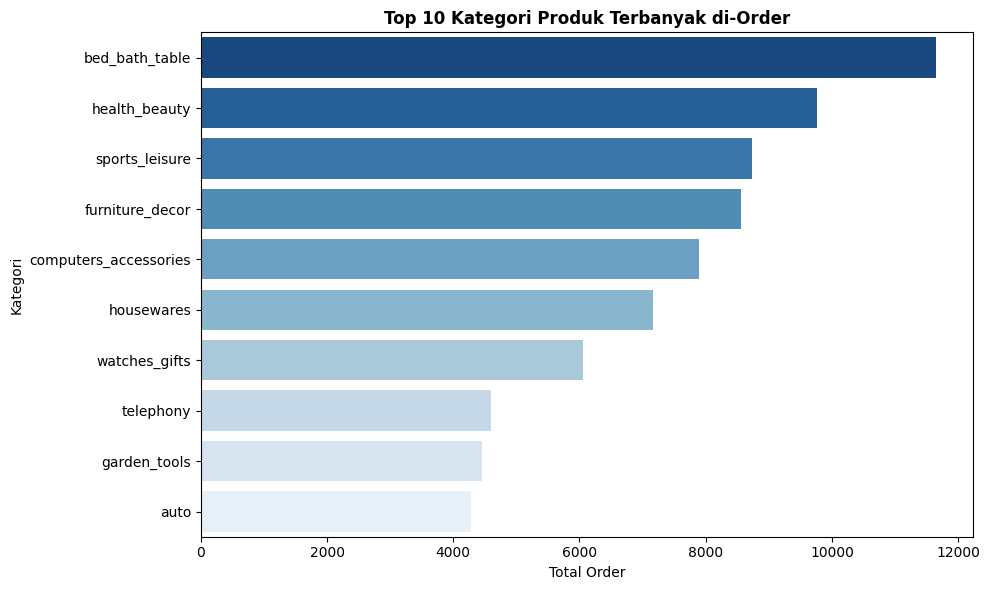

In [53]:
# Plot 1a: Total Order
plt.figure(figsize=(10, 6))
sns.barplot(data=top_category_order, x='total_order', y='category', palette='Blues_r')
plt.title('Top 10 Kategori Produk Terbanyak di-Order', fontweight='bold')
plt.xlabel('Total Order')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Kategori produk dengan revenue terbesar

/tmp/ipykernel_7262/363384575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_category_revenue, x='total_revenue',


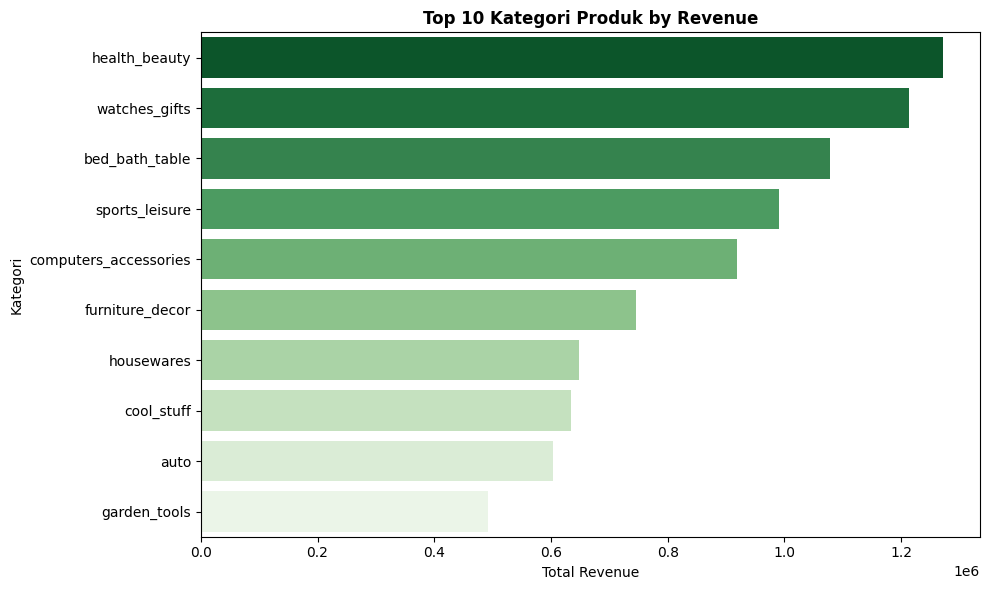

In [54]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_category_revenue, x='total_revenue',
y='category',palette='Greens_r')
plt.title('Top 10 Kategori Produk by Revenue', fontweight='bold')
plt.xlabel('Total Revenue')
plt.ylabel('Kategori')
plt.tight_layout()
plt.show()


**Pertanyaan 3: Visualisasi Tren Order Bulanan**

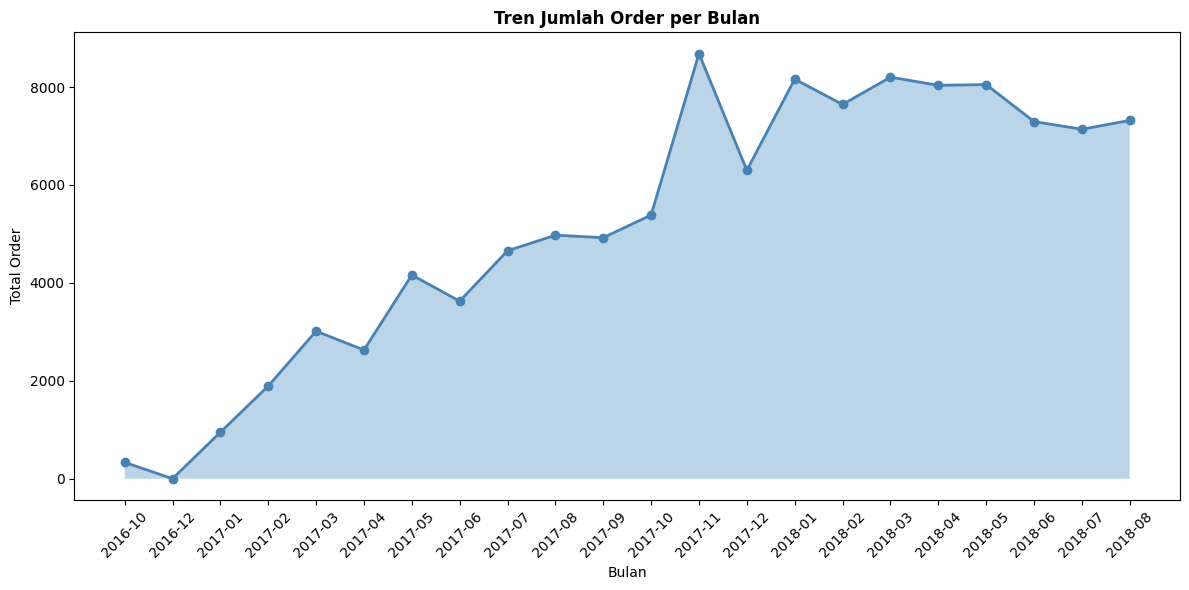

In [55]:
monthly_order['year_month_str'] = monthly_order['year_month'].astype(str)
plt.figure(figsize=(12, 6))
plt.plot(monthly_order['year_month_str'], monthly_order['total_order'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly_order['year_month_str'],
                 monthly_order['total_order'],alpha=0.3)
plt.title('Tren Jumlah Order per Bulan', fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Total Order')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Pertanyaan 4: Apakah pengiriman sudah sesuai estimasi?**

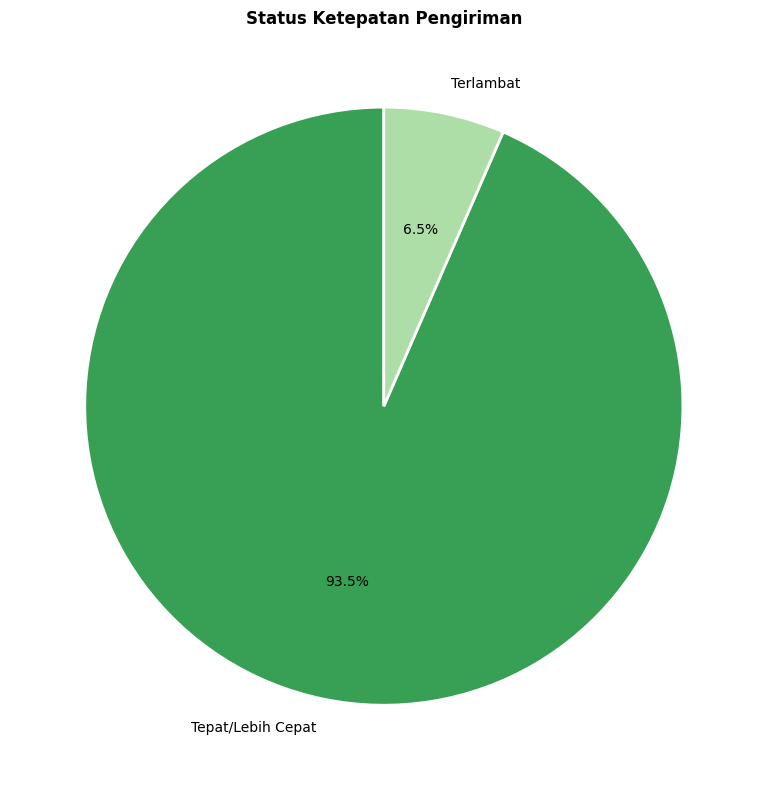

In [56]:
plt.figure(figsize=(8, 8))
colors = sns.color_palette('Greens_r', len(delivery_summary))
plt.pie(delivery_summary['total'], labels=delivery_summary['status'],
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Status Ketepatan Pengiriman', fontweight='bold')
plt.tight_layout()
plt.show()

**Pertanyaan 5: Kota dengan Pelanggan Terbanyak**

/tmp/ipykernel_7262/1673847816.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_city, x='total_customer', y='city', palette='Blues_r')


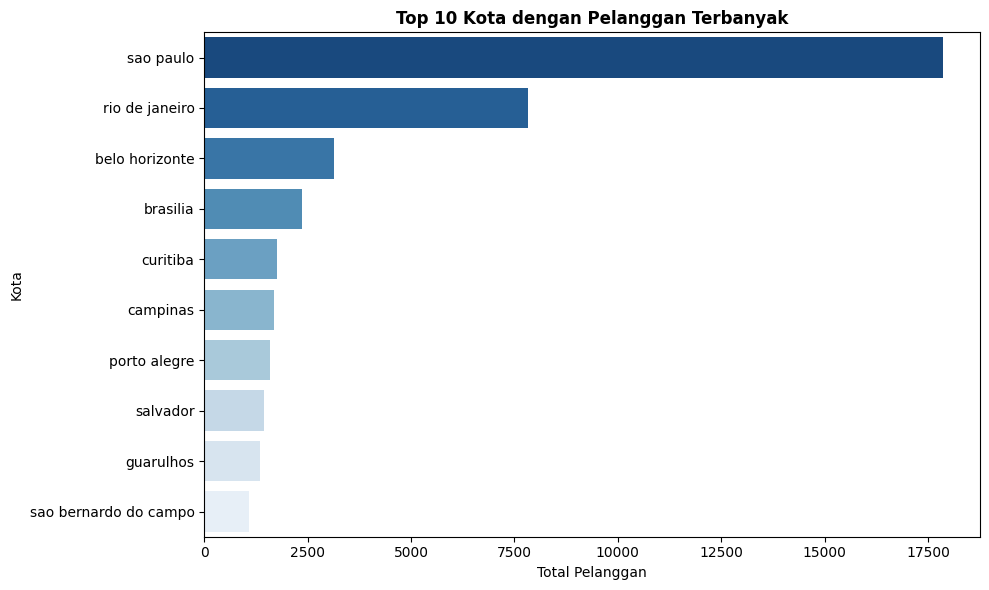

In [57]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_city, x='total_customer', y='city', palette='Blues_r')
plt.title('Top 10 Kota dengan Pelanggan Terbanyak', fontweight='bold')
plt.xlabel('Total Pelanggan')
plt.ylabel('Kota')
plt.tight_layout()
plt.show()

**Pertanyaan 6 : Metode Pembayaran yang paling sering dilakukan**

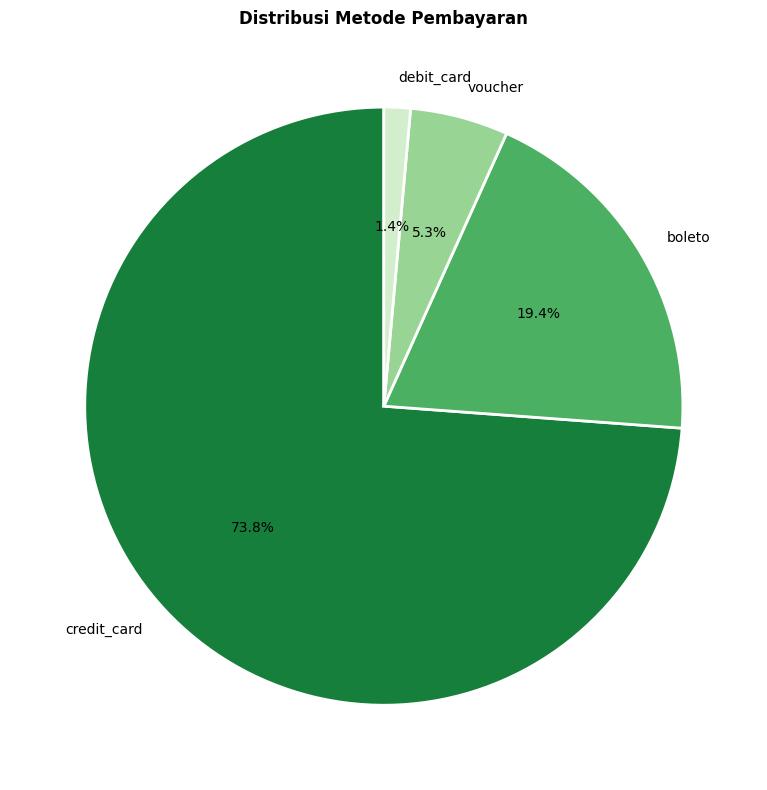

In [58]:
plt.figure(figsize=(8, 8))
colors = sns.color_palette('Greens_r', len(top_payment))
plt.pie(top_payment['total'], labels=top_payment['payment_type'],
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Distribusi Metode Pembayaran', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Produk yang paling banyak diorder adalah produk dengan kategori rumah tangga dengan total 11.800 order, dan produk yang sedikit order kurang dari 4.300 order
- Produk yang memiliki keuntungan terbanyak pada produk yang dijual yaitu produk kecantikan dengan total keuntungan $1,27 Juta Dollar
- Jumlah Order setiap bulan pada 2 tahun terakhir memiliki tren yang cenderung naik
- Pengiriman yang dilakukan cenderung tepat waktu
- Pelanggan terbanyak berada di kota Sao Paulo dengan total pelanggan 17500 pelanggan
- Pembayaran yang paling sering dilakukan adalah credit card

## Analisis Lanjutan (Opsional)

In [59]:
#hitung rfm
import pandas as pd
import numpy as np
from datetime import datetime

# Tentukan tanggal referensi (tanggal terakhir di data)
reference_date = main_df['order_purchase_timestamp'].max()

# Hitung RFM
rfm_df = main_df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('price', 'sum')
).reset_index()

print(rfm_df.head())
print(rfm_df.describe())

                 customer_unique_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      111          1    129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      114          1     18.90
2  0000f46a3911fa3c0805444483337064      536          1     69.00
3  0000f6ccb0745a6a4b88665a16c9f078      320          1     25.99
4  0004aac84e0df4da2b147fca70cf8255      287          1    180.00
            Recency     Frequency      Monetary
count  92063.000000  92063.000000  92063.000000
mean     236.244811      1.033097    147.988157
std      152.573703      0.206879    243.793692
min        0.000000      1.000000      0.850000
25%      113.000000      1.000000     48.900000
50%      217.000000      1.000000     89.900000
75%      345.000000      1.000000    159.900000
max      694.000000     14.000000  13440.000000


In [60]:
#normalisasi data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])

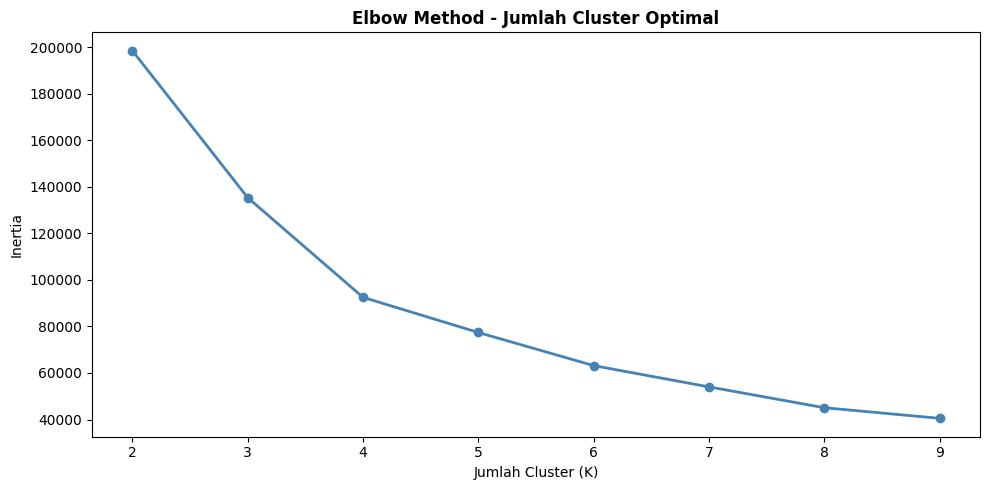

In [61]:
#cluster optimal (elbow method)
from sklearn.cluster import KMeans

inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow
plt.figure(figsize=(10, 5))
plt.plot(K, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Jumlah Cluster Optimal', fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.tight_layout()
plt.show()

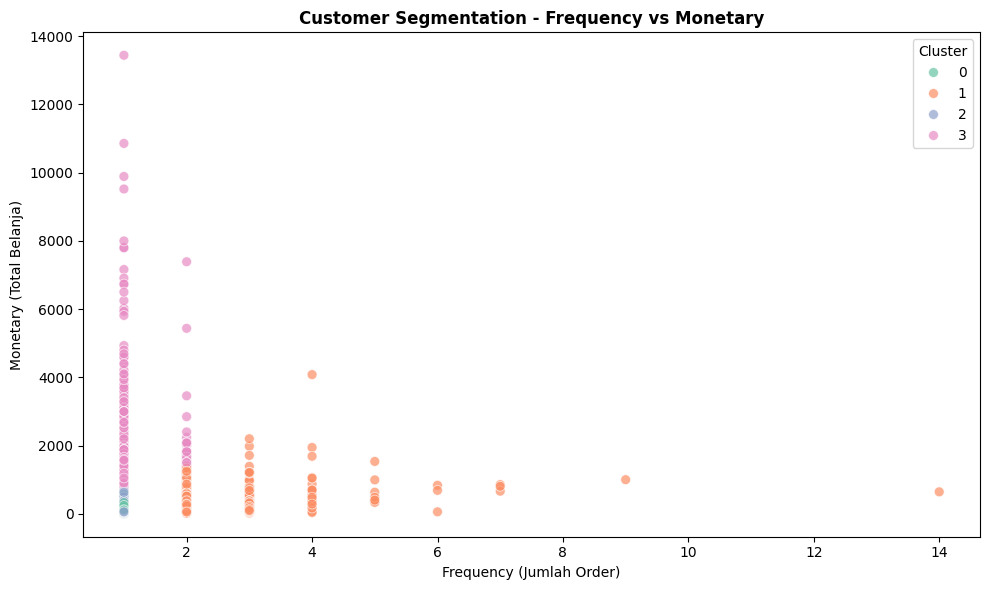

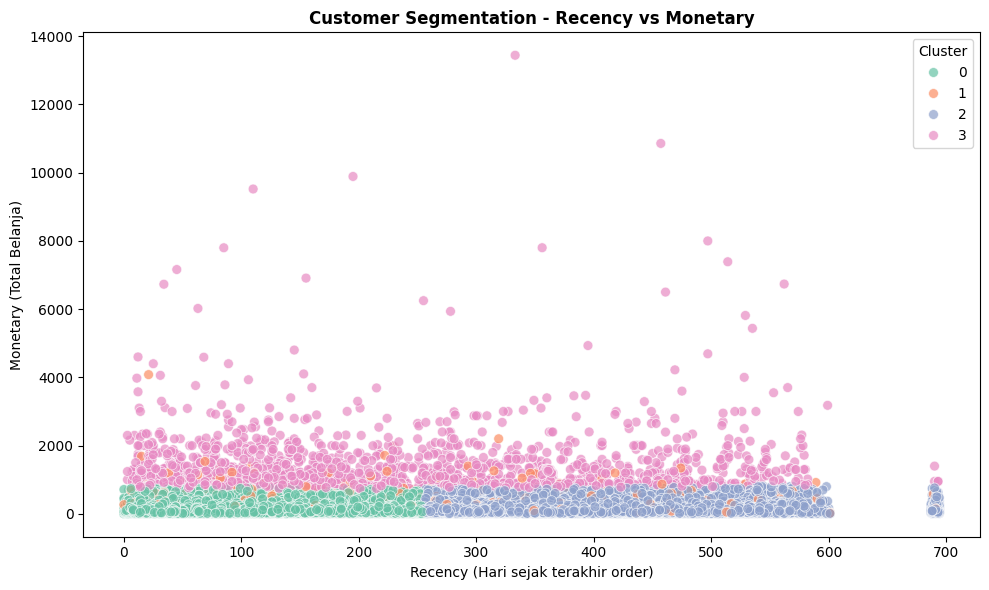

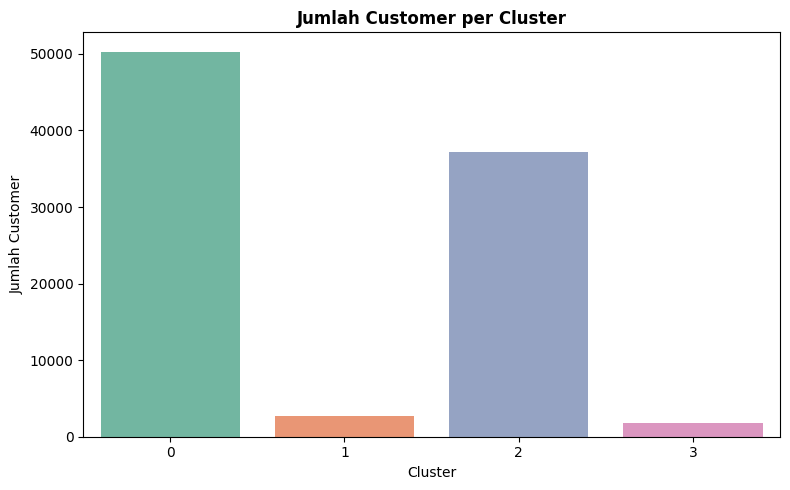

In [62]:
from sklearn.cluster import KMeans

# Assuming an optimal k (e.g., 3) from the elbow method, but without the plot, we'll pick 3 as a reasonable starting point.
k_optimal = 4 # You should choose this based on the elbow plot from the previous cell
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

#cluster visualization
# Plot 1: Scatter Frequency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary',
                hue='Cluster', palette='Set2', s=50, alpha=0.7)
plt.title('Customer Segmentation - Frequency vs Monetary', fontweight='bold')
plt.xlabel('Frequency (Jumlah Order)')
plt.ylabel('Monetary (Total Belanja)')
plt.tight_layout()
plt.show()

# Plot 2: Scatter Recency vs Monetary
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary',
                hue='Cluster', palette='Set2', s=50, alpha=0.7)
plt.title('Customer Segmentation - Recency vs Monetary', fontweight='bold')
plt.xlabel('Recency (Hari sejak terakhir order)')
plt.ylabel('Monetary (Total Belanja)')
plt.tight_layout()
plt.show()

# Plot 3: Jumlah Customer per Cluster
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm_df, x='Cluster', hue='Cluster', palette='Set2', legend=False)
plt.title('Jumlah Customer per Cluster', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Customer')
plt.tight_layout()
plt.show()

In [63]:
# Sesuaikan mapping dengan hasil cluster kamu
cluster_labels = {
    0: 'Hibernating',    # Recency tinggi, Frequency & Monetary rendah
    1: 'Loyal Customer', # Frequency & Monetary tinggi
    2: 'At Risk',        # Recency sedang, mulai jarang order
    3: 'Champion'        # Recency rendah, Frequency & Monetary tinggi
}

rfm_df['Segment'] = rfm_df['Cluster'].map(cluster_labels)
print(rfm_df['Segment'].value_counts())

Segment
Hibernating       50296
At Risk           37247
Loyal Customer     2715
Champion           1805
Name: count, dtype: int64


CONCLUSION - CUSTOMER SEGMENTATION ANALYSIS
============================================
Berdasarkan analisis RFM (Recency, Frequency, Monetary) menggunakan
K-Means Clustering dengan K=4, pelanggan dibagi menjadi 4 segmen:

1. HIBERNATING (50.296 pelanggan - 54.5%)
   - Segmen terbesar namun paling tidak aktif
   - Sudah sangat lama tidak melakukan transaksi
   - Frequency & Monetary rendah
   - Perlu strategi WIN-BACK campaign segera

2. AT RISK (37.247 pelanggan - 40.3%)
   - Segmen terbesar kedua yang mulai tidak aktif
   - Recency tinggi menandakan sudah lama tidak order
   - Masih ada peluang untuk direaktivasi
   - Perlu penawaran eksklusif sebelum benar-benar hilang

3. LOYAL CUSTOMER (2.715 pelanggan - 2.9%)
   - Pelanggan setia dengan frequency order tinggi
   - Perlu dipertahankan dengan loyalty program
   - Berpotensi naik menjadi Champion

4. CHAMPION (1.805 pelanggan - 1.9%)
   - Segmen terkecil namun paling bernilai
   - Monetary tertinggi hingga R$13.000+
   - Meski frequency rendah, nilai transaksi sangat besar
   - Perlu diperlakukan sebagai VIP

## Conclusion

## 📌 Conclusion

### Pertanyaan 1: Kategori Produk Terlaris & Revenue Tertinggi
Berdasarkan analisis kategori produk, ditemukan bahwa **bed_bath_table**
merupakan kategori dengan jumlah order terbanyak (~11.800 order),
menunjukkan tingginya permintaan produk kebutuhan rumah tangga.
Namun dari sisi revenue, **health_beauty** justru memimpin dengan
total pendapatan ~R$1.27 juta, diikuti **watches_gifts** di posisi kedua
meski hanya berada di rank ke-7 dari sisi jumlah order.
Hal ini menunjukkan bahwa produk kecantikan dan jam tangan/hadiah
memiliki nilai jual per item yang lebih tinggi dibandingkan kategori lainnya.

### Pertanyaan 2: Tren Order Bulanan & Ketepatan Pengiriman
Tren order menunjukkan pertumbuhan yang signifikan sepanjang periode
analisis, dengan puncak order terjadi pada akhir tahun 2017.
Dari sisi ketepatan pengiriman, mayoritas order berhasil dikirimkan
tepat waktu atau lebih cepat dari estimasi, menandakan performa
logistik yang cukup baik. Namun masih terdapat sebagian order
yang terlambat sehingga perlu menjadi perhatian untuk ditingkatkan.

### Pertanyaan 3: Kota dengan Pelanggan Terbanyak
Analisis geografis menunjukkan bahwa **Sao Paulo** mendominasi
sebagai kota dengan pelanggan terbanyak, jauh melampaui kota-kota
lainnya. Hal ini wajar mengingat Sao Paulo merupakan kota terbesar
dan pusat ekonomi Brazil. Konsentrasi pelanggan di kota-kota besar
menunjukkan potensi ekspansi yang besar ke kota-kota tier 2 dan 3
yang belum tergarap secara maksimal.

### Pertanyaan 4: Metode Pembayaran Terpopuler
**Credit card** menjadi metode pembayaran yang paling dominan
digunakan pelanggan, mengindikasikan bahwa pelanggan lebih
menyukai kemudahan pembayaran dengan kartu kredit.
Boleto (slip pembayaran) berada di posisi kedua,
mencerminkan kebiasaan pembayaran masyarakat Brazil yang
masih cukup tinggi menggunakan metode konvensional.

### Analisis Lanjutan: Customer Segmentation (RFM)
Analisis RFM dengan K-Means Clustering (K=4) menghasilkan
4 segmen pelanggan dengan karakteristik berbeda:

| Segment | Jumlah | Persentase | Karakteristik |
|---|---|---|---|
| Hibernating | 50.296 | 54.5% | Sangat lama tidak transaksi |
| At Risk | 37.247 | 40.3% | Mulai tidak aktif |
| Loyal Customer | 2.715 | 2.9% | Aktif & sering repeat order |
| Champion | 1.805 | 1.9% | High value, transaksi terbesar |

Temuan kritis menunjukkan **94.8% pelanggan tidak aktif**
(Hibernating & At Risk), sementara hanya **4.7% pelanggan aktif**
(Loyal & Champion). Bisnis perlu segera mengambil tindakan
untuk mereaktivasi pelanggan yang tidak aktif.



**SIMPAN DATA**

In [64]:
# SIMPAN SEMUA DATA YANG DIBUTUHKAN

# 1. Simpan main_df
main_df.to_csv('main_data.csv', index=False)

# 2. Simpan rfm_df hasil clustering
rfm_df.to_csv('rfm_data.csv', index=False)

# 3. Simpan data EDA
top_category_order.to_csv('top_category_order.csv', index=False)
top_category_revenue.to_csv('top_category_revenue.csv', index=False)
monthly_order.to_csv('monthly_order.csv', index=False)
delivery_summary.to_csv('delivery_summary.csv', index=False)
top_city.to_csv('top_city.csv', index=False)
top_payment.to_csv('top_payment.csv', index=False)

print("✅ Semua data berhasil disimpan!")

✅ Semua data berhasil disimpan!
